# Esercizio 08 — Variational Monte Carlo e Simulated Annealing

In questo notebook studio lo stato fondamentale di una particella quantistica unidimensionale nel potenziale

$$
V(x)=x^4-\frac{5}{2}x^2.
$$

L'obiettivo è stimare l'energia del ground state con un metodo variazionale. Prima fisso i parametri della funzione d'onda trial e verifico il funzionamento del Variational Monte Carlo. Poi ottimizzo i parametri con un Simulated Annealing nello spazio $(\mu,\sigma)$ e, solo alla fine, eseguo una VMC lunga sui parametri selezionati.

## Principio variazionale

Il principio variazionale afferma che, per una qualunque funzione d'onda di prova normalizzabile $\Psi_T$, il valore medio dell'Hamiltoniana è sempre maggiore o uguale all'energia fondamentale esatta:

$$
\langle H\rangle_T=
\frac{\langle\Psi_T|\hat H|\Psi_T\rangle}{\langle\Psi_T|\Psi_T\rangle}
\geq E_0.
$$

Questa proprietà è il punto centrale dell'esercizio: cambiando i parametri della funzione trial si cerca di abbassare $\langle H\rangle_T$, ma il valore medio esatto non può scendere sotto $E_0$. Se durante una simulazione Monte Carlo una stima singola finisce sotto il riferimento numerico, la causa non è una violazione del principio variazionale, ma una fluttuazione statistica dovuta al campionamento finito.

## Funzione d'onda di prova

La funzione d'onda trial usata nell'esercizio è

$$
\Psi_T^{\sigma,\mu}(x) \propto
\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]
+
\exp\left[-\frac{(x+\mu)^2}{2\sigma^2}\right].
$$

È la somma di due gaussiane simmetriche centrate in $+\mu$ e $-\mu$. Questa forma è adatta al potenziale a doppia buca, perché permette alla densità di probabilità di concentrarsi nelle due regioni di minimo del potenziale.

Il parametro $\mu$ controlla la distanza tra i due picchi, mentre $\sigma$ controlla la larghezza delle gaussiane. Se $\mu$ è troppo piccolo, la funzione d'onda rimane troppo concentrata al centro; se $\mu$ è troppo grande, i picchi finiscono troppo lontani. Analogamente, se $\sigma$ è troppo piccolo la funzione è troppo stretta e aumenta il contributo cinetico, mentre se è troppo grande la funzione si spalma troppo anche in regioni energeticamente sfavorevoli.

## Energia locale

Nel Variational Monte Carlo non calcolo l'integrale variazionale tramite un'integrazione numerica diretta su tutto lo spazio. Campiono invece le posizioni $x$ secondo la densità di probabilità $|\Psi_T(x)|^2$ e calcolo, per ogni punto campionato, l'energia locale

$$
E_L(x)=\frac{\hat H\Psi_T(x)}{\Psi_T(x)}
=-\frac{1}{2}\frac{\Psi_T''(x)}{\Psi_T(x)}+V(x),
$$

dove ho usato $\hbar=1$ e $m=1$.

La media di $E_L(x)$ sui punti estratti con Metropolis fornisce quindi la stima Monte Carlo dell'energia variazionale $\langle H\rangle_T$. Nel codice C++ il nucleo del calcolo è:

```cpp
double local_energy(double x, double mu, double sigma) {
    double sigma2 = sigma * sigma;
    double sigma4 = sigma2 * sigma2;

    double g1 = exp(-pow(x - mu, 2) / (2.0 * sigma2));
    double g2 = exp(-pow(x + mu, 2) / (2.0 * sigma2));

    double psi = g1 + g2;

    double psi_second =
        g1 * (pow(x - mu, 2) / sigma4 - 1.0 / sigma2)
      + g2 * (pow(x + mu, 2) / sigma4 - 1.0 / sigma2);

    return -0.5 * psi_second / psi + potential(x);
}
```

La variabile `psi_second` rappresenta $\Psi_T''(x)$, cioè la derivata seconda della funzione d'onda di prova rispetto a $x$. Infatti la derivata seconda di una gaussiana del tipo

$$
g_a(x)=e^{-(x-a)^2/(2\sigma^2)}
$$

è

$$
g_a''(x)=\left[\frac{(x-a)^2}{\sigma^4}-\frac{1}{\sigma^2}\right]g_a(x).
$$

Poiché $\Psi_T(x)$ è la somma di due gaussiane centrate in $+\mu$ e $-\mu$, la sua derivata seconda è la somma delle due derivate seconde.

## Setup Python

Le celle seguenti caricano i risultati prodotti dal codice C++.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (8.5, 5.5),
    "figure.dpi": 120,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.8,
    "legend.frameon": True,
})

RESULTS = Path("results")

def read_table(filename, names):
    path = RESULTS / filename
    if not path.exists():
        raise FileNotFoundError(f"File non trovato: {path}")
    return pd.read_csv(
        path,
        comment="#",
        sep=r"\s+|;",
        engine="python",
        header=None,
        names=names,
    )

## Soluzione numerica di riferimento

Per avere un riferimento indipendente diagonalizzo numericamente l'Hamiltoniana. Il problema fisico è definito su tutto l'asse reale, ma al calcolatore devo lavorare su un intervallo finito. Scelgo quindi una scatola numerica $[-a/2,a/2]$ con $a=10$, cioè $x\in[-5,5]$. Per questo potenziale l'intervallo è sufficientemente grande, perché $V(x)$ cresce rapidamente per $|x|$ grande e la funzione d'onda fondamentale è trascurabile vicino ai bordi.

Sulla griglia approssimo la derivata seconda con differenze finite:

$$
\psi''(x_i)\simeq
\frac{\psi(x_{i+1})-2\psi(x_i)+\psi(x_{i-1})}{dx^2}.
$$

L'Hamiltoniana discretizzata diventa quindi una matrice tridiagonale. La diagonale contiene il termine cinetico $1/dx^2$ più il potenziale $V(x_i)$, mentre le diagonali immediatamente sopra e sotto valgono $-1/(2dx^2)$. Diagonalizzando questa matrice ottengo il valore numerico di riferimento $E_0$ e la densità $|\psi_0(x)|^2$ dello stato fondamentale.

Energia fondamentale numerica: E0 = -0.4604658797


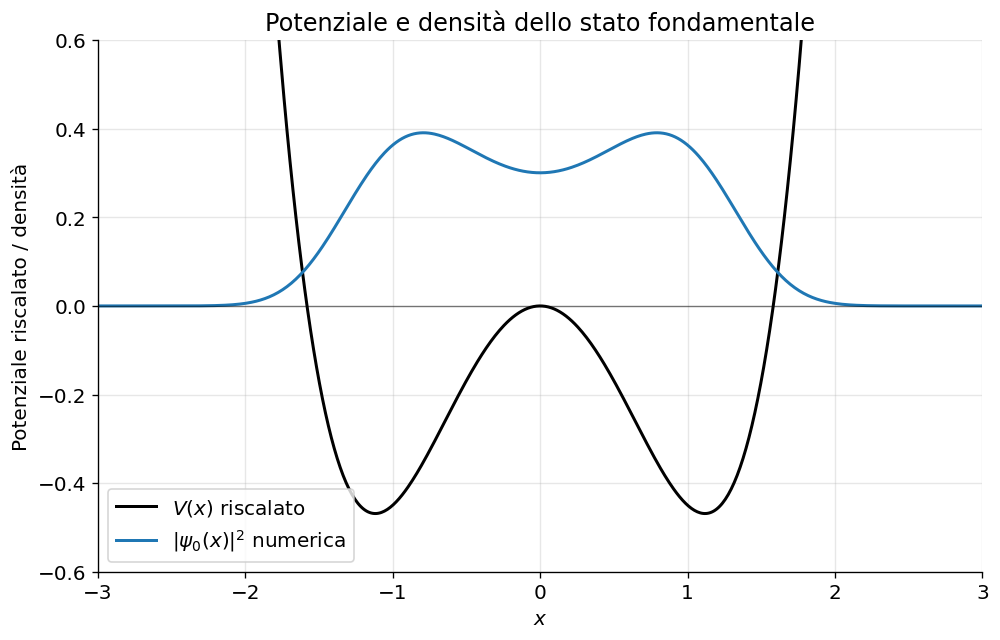

In [2]:
def potential(x):
    return x**4 - 2.5*x**2


# Diagonalizzazione numerica dell'Hamiltoniana.
# Uso solo l'autovalore più basso, perché mi interessa lo stato fondamentale.
a = 10.0
n_grid = 1000

x_exact = np.linspace(-a / 2, a / 2, n_grid)
dx = x_exact[1] - x_exact[0]

diagonal = 1.0 / dx**2 + potential(x_exact)
off_diagonal = -0.5 / dx**2 * np.ones(n_grid - 1)

from scipy.linalg import eigh_tridiagonal

eigenvalues, eigenvectors = eigh_tridiagonal(
    diagonal,
    off_diagonal,
    select="i",
    select_range=(0, 0),
)

E0 = eigenvalues[0]

# Converto l'autovettore discreto in una funzione d'onda continua: se sum_i |v_i|^2 = 1, allora psi_i = v_i/sqrt(dx) dà sum_i |psi_i|^2 dx = 1.
psi0 = eigenvectors[:, 0] / np.sqrt(dx)

print(f"Energia fondamentale numerica: E0 = {E0:.10f}")


# Regione mostrata nel grafico.
mask = (x_exact >= -3.0) & (x_exact <= 3.0)

x_plot = x_exact[mask]
density0 = psi0[mask]**2

# Potenziale non traslato: viene solo riscalato per stare nello stesso grafico.
potential_scale = 0.30
V_plot = potential_scale * potential(x_plot)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.plot(x_plot, V_plot, color="black", label=r"$V(x)$ riscalato")
ax.plot(x_plot, density0, label=r"$|\psi_0(x)|^2$ numerica")

ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-0.6, 0.6)

ax.set_xlabel(r"$x$")
ax.set_ylabel("Potenziale riscalato / densità")
ax.set_title("Potenziale e densità dello stato fondamentale")

ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

# Esercizio 08.1

## Metodo

Nella prima parte scelgo parametri fissati della funzione trial e stimo $\langle H\rangle_T$ con Variational Monte Carlo. In questa run uso

$$
\mu = 1.0, \qquad \sigma = 0.5.
$$

Il Metropolis campiona la densità $|\Psi_T^{\mu,\sigma}(x)|^2$ con mosse uniformi

$$
x' = x + \delta, \qquad \delta \in [-\Delta x,\Delta x],
$$

con $\Delta x=1.2$. Prima della misura eseguo $10000$ passi di equilibrazione, che non entrano nelle medie. La misura è poi divisa in $100$ blocchi da $1000$ passi Metropolis ciascuno. In questo modo posso stimare l'incertezza statistica tramite data blocking.

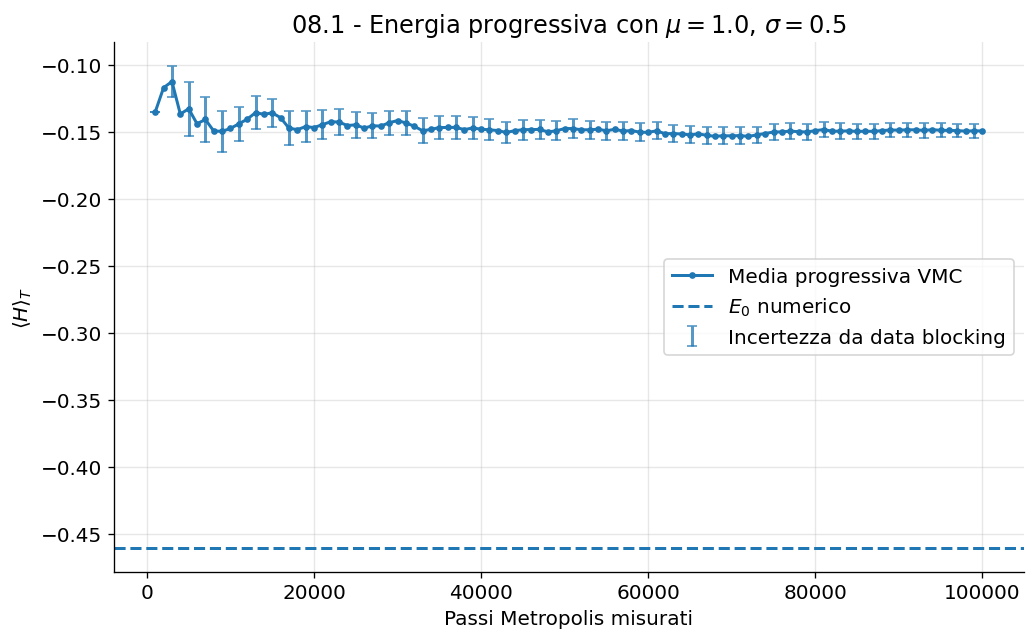

<H> = -0.1494 +/- 0.0050
Acceptance media = 0.5028


In [3]:
# Parametri della run 08.1.
blocks_81 = 100
steps_per_block_81 = 1000
equilibration_81 = 10000
mu_81 = 1.0
sigma_81 = 0.5

data_81 = read_table(
    "metropolis_08_1.txt",
    ["block", "progressive_energy", "error", "block_energy", "acceptance"],
)

data_81["mc_steps"] = data_81["block"] * steps_per_block_81

# Mostro tutti i punti con una linea e le barre d'errore solo su un sottoinsieme,
# così il grafico resta leggibile anche con molti blocchi.
err_stride_81 = max(1, len(data_81) // 40)

fig, ax = plt.subplots(figsize=(8.8, 5.5))
ax.plot(
    data_81["mc_steps"],
    data_81["progressive_energy"],
    marker="o",
    markersize=3,
    label="Media progressiva VMC",
)
ax.errorbar(
    data_81["mc_steps"].iloc[::err_stride_81],
    data_81["progressive_energy"].iloc[::err_stride_81],
    yerr=data_81["error"].iloc[::err_stride_81],
    fmt="none",
    capsize=3,
    alpha=0.75,
    label="Incertezza da data blocking",
)
ax.axhline(E0, linestyle="--", label=r"$E_0$ numerico")
ax.set_xlabel("Passi Metropolis misurati")
ax.set_ylabel(r"$\langle H \rangle_T$")
ax.set_title(r"08.1 - Energia progressiva con $\mu=1.0$, $\sigma=0.5$")
ax.legend()
fig.tight_layout()
plt.show()

final_81 = data_81.iloc[-1]
print(f"<H> = {final_81['progressive_energy']:.4f} +/- {final_81['error']:.4f}")
print(f"Acceptance media = {data_81['acceptance'].mean():.4f}")

## Commento a 08.1

Questa prima run non deve ancora fornire una buona approssimazione dell'energia fondamentale: i parametri $\mu=1.0$ e $\sigma=0.5$ sono solo una scelta iniziale. Il suo scopo è verificare che il codice VMC funzioni correttamente: la media progressiva deve stabilizzarsi e l'errore deve diminuire all'aumentare del numero di blocchi.

Il valore ottenuto è più alto di $E_0$, come previsto dal principio variazionale. La differenza è però grande, perché la funzione trial non è ancora ottimizzata. Nella parte successiva uso il Simulated Annealing per cercare parametri più favorevoli.

# Esercizio 08.2

## Metodo: Simulated Annealing nello spazio dei parametri

Nella seconda parte ottimizzo i parametri $\mu$ e $\sigma$. Il Simulated Annealing è un Metropolis esterno nello spazio dei parametri variazionali: a ogni passo propongo una nuova coppia $(\mu',\sigma')$, stimo con una VMC l'energia corrispondente e decido se accettare o rifiutare la mossa.

La probabilità di accettazione è

$$
A=\min\left(1, e^{-\beta(E_{new}-E_{old})}\right),
$$

con $\beta=1/T$. Quando la temperatura è alta, l'algoritmo accetta più facilmente anche mosse che peggiorano l'energia e quindi esplora lo spazio dei parametri. Quando la temperatura si abbassa, le mosse peggiorative diventano sempre meno probabili e la traiettoria si concentra vicino a una regione di minimo.

Uso una schedule del tipo

$$
T_i=\frac{T_0}{i+1},
$$

con $T_0=10$, quindi $T_i=10/(i+1)$.

## Parametri numerici della run SA

Durante il Simulated Annealing l'energia deve essere stimata molte volte, quindi non usiamo subito una statistica enorme. Ho scelto una statistica intermedia: abbastanza leggera da rendere praticabile l'ottimizzazione, ma non troppo piccola da rendere completamente rumoroso il confronto tra due coppie di parametri.

Per ogni stima veloce dell'energia durante il SA uso:

- blocchi VMC: $100$;
- passi Metropolis per blocco: $1000$;
- passi di equilibrazione: $1000$;

I passi di proposta iniziali nello spazio dei parametri sono

$$
\Delta\mu=0.08, \qquad \Delta\sigma=0.05.
$$

Durante il SA li adatto in modo semplice: se l'accettazione a una temperatura è troppo alta, aumento leggermente i passi; se è troppo bassa, li riduco. Questo adattamento riguarda solo lo spazio dei parametri $(\mu,\sigma)$, non il passo Metropolis in $x$.

Per evitare che il minimo scelto sia solo una fluttuazione statistica favorevole, quando trovo un candidato migliore lo ricontrollo con una statistica più alta:

- blocchi per il controllo del best: $100$;
- passi per blocco nel controllo: $2000$;
- passi di equilibrazione nel controllo: $5000$;

Infine, per il risultato da riportare nel notebook, faccio una run VMC lunga sui parametri ottimizzati:

- blocchi finali: $100$;
- passi Metropolis per blocco nella run finale: $10000$;
- passi di equilibrazione finali: $10000$;

La parte centrale del Simulated Annealing è questa. La temperatura segue $T_i=T_0/(i+1)$ per 1000 temperature e, ad ognuna, propongo 100 mosse uniformi in $\mu$ e $\sigma$:

```cpp
double temperature = T0 / pow(double(itemp + 1), cooling_power);
double beta = 1.0 / temperature;

double mu_new = mu + rnd.Rannyu(-delta_mu, delta_mu);
double sigma_new = sigma + rnd.Rannyu(-delta_sigma, delta_sigma);
```

Se la coppia proposta è fisicamente accettabile, cioè se $\mu>0$ e $\sigma>0$, stimo l'energia con una VMC veloce e applico la regola di Metropolis:

```cpp
double delta_energy = proposed.mean - current.mean;

double acceptance_probability = 1.0;
if (delta_energy > 0.0) {
    acceptance_probability = exp(-beta * delta_energy);
}
```

Quando la stima veloce suggerisce un nuovo minimo, faccio un controllo più accurato prima di aggiornare il best. Questo passaggio è importante perché evita di scegliere come ottimo un punto che sembra buono solo per una fluttuazione Monte Carlo.

In [4]:
sa_columns = [
    "step",
    "beta",
    "temperature",
    "mu",
    "sigma",
    "energy",
    "error",
    "accepted",
    "best_energy",
    "best_error",
    "best_mu",
    "best_sigma",
    "acceptance",
    "delta_mu",
    "delta_sigma",
]

sa = pd.read_csv(
    RESULTS / "annealing_08_2.txt",
    comment="#",
    sep=r"\s+",
    header=None,
    names=sa_columns,
)

sa["accepted"] = sa["accepted"].astype(bool)

best_mu = sa["best_mu"].iloc[-1]
best_sigma = sa["best_sigma"].iloc[-1]
best_energy = sa["best_energy"].iloc[-1]
best_error = sa["best_error"].iloc[-1]

print(f"Best ricontrollato: mu = {best_mu:.6f}, sigma = {best_sigma:.6f}")
print(f"H_stimata = {best_energy:.6f} +/- {best_error:.6f}")

Best ricontrollato: mu = 0.805468, sigma = 0.616295
H_stimata = -0.449305 +/- 0.001333


## Energia durante il Simulated Annealing

Durante il Simulated Annealing ogni punto nello spazio dei parametri $(\mu,\sigma)$ viene valutato tramite una simulazione VMC relativamente breve. Le energie mostrate come punti sono quindi stime veloci e rumorose, usate solo per guidare l'algoritmo.

Nel file di output l'energia corrente viene salvata a ogni step del SA, anche quando la nuova proposta viene rifiutata. A basse temperature, dove l'acceptance diventa piccola, lo stesso valore può quindi essere ripetuto molte volte. Per rendere il grafico più leggibile considero solo le mosse accettate.

La linea continua rappresenta invece il miglior punto ricontrollato con una statistica maggiore. Questa curva non è una media mobile: è il valore del `best_energy` mantenuto dall'algoritmo dopo il controllo più accurato. Il valore numerico esatto $E_0$ è riportato come riferimento. Alcune singole stime veloci possono cadere sotto $E_0$ per fluttuazione statistica; questo non viola il principio variazionale, che riguarda il valore medio esatto e non una singola stima Monte Carlo con statistica limitata.

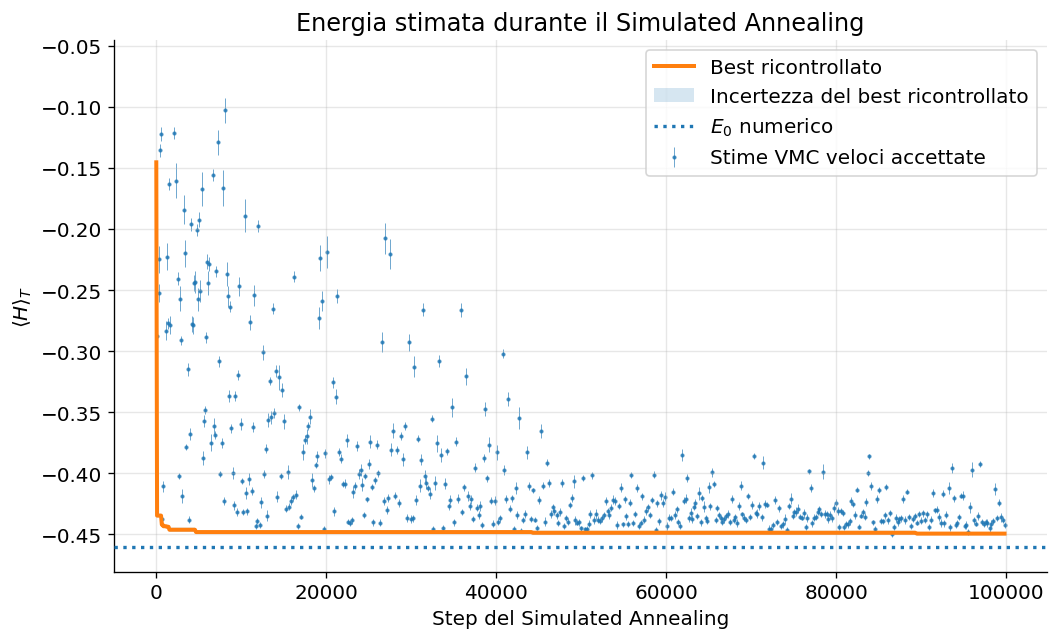

In [5]:
# Considero solo gli step in cui la proposta nello spazio dei parametri è stata accettata.
sa_accepted = sa[sa["accepted"]].copy()

# Seleziono al massimo circa 500 punti disegnati.
plot_stride = max(1, len(sa_accepted) // 500)

sa_plot = sa_accepted.iloc[::plot_stride].copy()

fig, ax = plt.subplots(figsize=(9.0, 5.5))

# Stime veloci e rumorose usate dal SA.
ax.errorbar(
    sa_plot["step"],
    sa_plot["energy"],
    yerr=sa_plot["error"],
    fmt=".",
    markersize=3,
    linewidth=0.5,
    elinewidth=0.5,
    capsize=0,
    alpha=0.75,
    label="Stime VMC veloci accettate",
    zorder=1,
)

# Best ricontrollato con statistica maggiore.
# Lo metto sopra ai punti per renderlo leggibile.
ax.plot(
    sa_plot["step"],
    sa_plot["best_energy"],
    linewidth=2.4,
    label="Best ricontrollato",
    zorder=3,
)

# Incertezza del best ricontrollato.
ax.fill_between(
    sa_plot["step"],
    sa_plot["best_energy"] - sa_plot["best_error"],
    sa_plot["best_energy"] + sa_plot["best_error"],
    alpha=0.18,
    label="Incertezza del best ricontrollato",
    zorder=2,
)

ax.axhline(
    E0,
    linestyle=":",
    linewidth=2.0,
    label=r"$E_0$ numerico",
    zorder=4,
)

# Limiti robusti: evito che i primi valori molto alti schiaccino la regione interessante.
y_max = sa["best_energy"].iloc[0] + 0.1
y_min = E0 - 0.02
ax.set_ylim(y_min, y_max)

ax.set_xlabel("Step del Simulated Annealing")
ax.set_ylabel(r"$\langle H \rangle_T$")
ax.set_title("Energia stimata durante il Simulated Annealing")
ax.legend(loc="best")

fig.tight_layout()
plt.show()

## Traiettoria nello spazio dei parametri

La traiettoria nel piano $(\mu,\sigma)$ permette di vedere come il Simulated Annealing esplora inizialmente una regione più ampia e poi si concentra vicino alla zona di minimo. I punti sono colorati in base allo step del SA: in questo modo si distingue la parte iniziale della simulazione dalla fase finale a temperatura bassa.

Il punto segnato come best controllato non è necessariamente l'ultimo punto della traiettoria. È il miglior candidato ricontrollato con statistica più alta, e sarà quello usato nella run VMC finale.

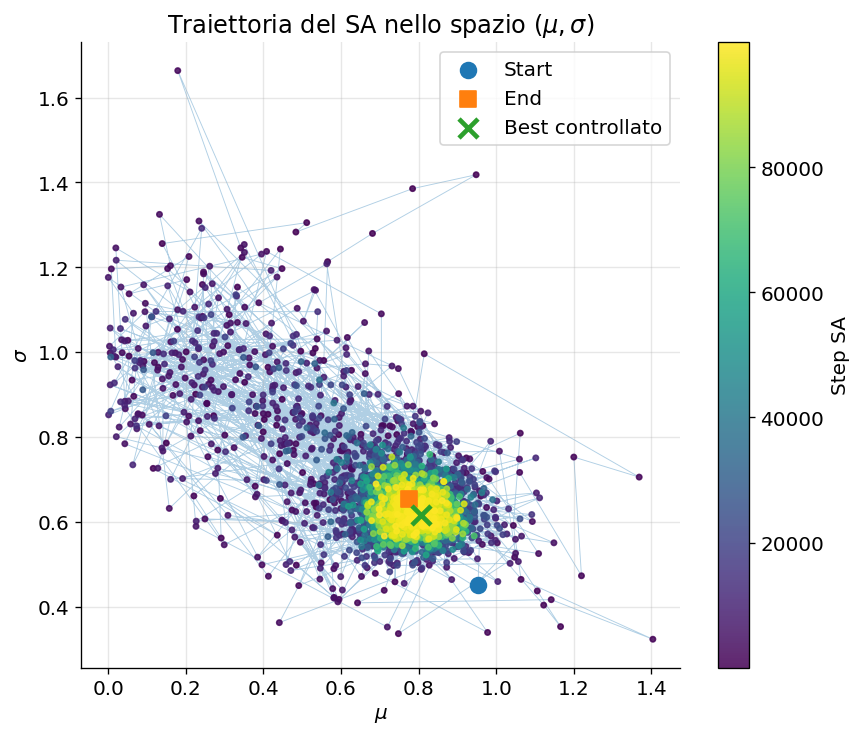

Best point selected after the check:
mu = 0.805468
sigma = 0.616295
H_checked = -0.449305 +/- 0.001333


In [6]:
traj_stride = max(1, len(sa) // 6000)
traj = sa.iloc[::traj_stride].copy()

best_mu = sa["best_mu"].iloc[-1]
best_sigma = sa["best_sigma"].iloc[-1]
best_energy = sa["best_energy"].iloc[-1]
best_error = sa["best_error"].iloc[-1] if "best_error" in sa.columns else np.nan

fig, ax = plt.subplots(figsize=(7.4, 6.3))

# Linea sottile che collega i punti successivi della traiettoria.
ax.plot(
    traj["mu"],
    traj["sigma"],
    linewidth=0.55,
    alpha=0.35,
    zorder=1,
)

# I punti sono colorati in base allo step.
scatter = ax.scatter(
    traj["mu"],
    traj["sigma"],
    c=traj["step"],
    cmap="viridis",
    s=10,
    alpha=0.85,
    zorder=2,
)

ax.scatter(sa["mu"].iloc[0], sa["sigma"].iloc[0], s=90, marker="o", label="Start", zorder=4)
ax.scatter(sa["mu"].iloc[-1], sa["sigma"].iloc[-1], s=90, marker="s", label="End", zorder=4)
ax.scatter(best_mu, best_sigma, s=130, marker="x", linewidths=2.8, label="Best controllato", zorder=5)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.set_title(r"Traiettoria del SA nello spazio $(\mu,\sigma)$")
fig.colorbar(scatter, ax=ax, label="Step SA")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

print("Best point selected after the check:")
print(f"mu = {best_mu:.6f}")
print(f"sigma = {best_sigma:.6f}")
if np.isfinite(best_error):
    print(f"H_checked = {best_energy:.6f} +/- {best_error:.6f}")
else:
    print(f"H_best = {best_energy:.6f}")

## Commento sul Simulated Annealing

Durante il SA alcune stime veloci dell'energia possono risultare molto basse, anche sotto il valore numerico di riferimento $E_0$. Questo non significa che il principio variazionale sia violato. Ogni valore durante il SA è ottenuto con una VMC relativamente breve, quindi contiene una fluttuazione statistica. Quando si fanno moltissime stime, è normale che qualcuna risulti artificialmente troppo bassa.

Per questo motivo non uso direttamente il minimo grezzo del SA. Lo considero solo un'indicazione della zona interessante nello spazio dei parametri e lo ricontrollo con più blocchi e più passi per blocco. Solo dopo questo controllo scelgo i parametri da usare nella run finale.

Anche il fatto che, verso la fine, $\Delta\mu$ e $\Delta\sigma$ diventino estremamente piccoli non ha un significato fisico. A temperatura molto bassa l'algoritmo è quasi congelato; se l'accettazione resta nulla per molte temperature consecutive, la regola di adattamento continua a ridurre i passi. La parte fisicamente rilevante è che la traiettoria si sia stabilizzata vicino a una regione di minimo, non il valore microscopico raggiunto dai passi alla fine.

# Run VMC finale ai parametri ottimizzati

La run finale è quella da usare come risultato fisico dell'esercizio. Qui i parametri sono fissati al best ricontrollato e aumento la statistica:

- numero di blocchi: $100$;
- passi Metropolis per blocco: $10000$;
- passi di equilibrazione: $10000$;
- passo Metropolis: $\Delta x=2.0$.

Questa separazione è importante: il SA serve a trovare parametri buoni, mentre la VMC finale serve a misurare l'energia con incertezza statistica affidabile.

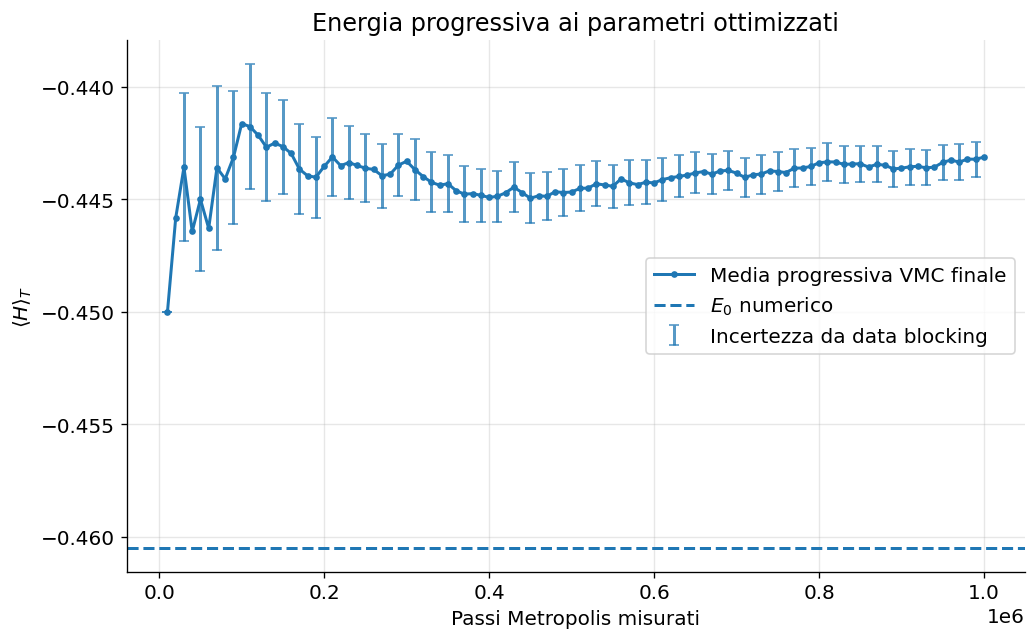

mu = 0.805468
sigma = 0.616295
<H> = -0.443130 +/- 0.000777
E0 numerico = -0.460466
Acceptance media finale = 0.6103


In [7]:
final_blocks = 100
final_steps_per_block = 10000
final_equilibration_steps = 10000

final_energy = read_table(
    "metropolis_08_3.txt",
    ["block", "progressive_energy", "error", "block_energy", "acceptance"],
)
final_energy["mc_steps"] = final_energy["block"] * final_steps_per_block

err_stride_final = max(1, len(final_energy) // 50)

fig, ax = plt.subplots(figsize=(8.8, 5.5))
ax.plot(
    final_energy["mc_steps"],
    final_energy["progressive_energy"],
    marker="o",
    markersize=3,
    label="Media progressiva VMC finale",
)
ax.errorbar(
    final_energy["mc_steps"].iloc[::err_stride_final],
    final_energy["progressive_energy"].iloc[::err_stride_final],
    yerr=final_energy["error"].iloc[::err_stride_final],
    fmt="none",
    capsize=3,
    alpha=0.75,
    label="Incertezza da data blocking",
)
ax.axhline(E0, linestyle="--", label=r"$E_0$ numerico")
ax.set_xlabel("Passi Metropolis misurati")
ax.set_ylabel(r"$\langle H \rangle_T$")
ax.set_title("Energia progressiva ai parametri ottimizzati")
ax.legend()
fig.tight_layout()
plt.show()

final_row = final_energy.iloc[-1]
final_mu = best_mu
final_sigma = best_sigma

print(f"mu = {final_mu:.6f}")
print(f"sigma = {final_sigma:.6f}")
print(f"<H> = {final_row['progressive_energy']:.6f} +/- {final_row['error']:.6f}")
print(f"E0 numerico = {E0:.6f}")
print(f"Acceptance media finale = {final_energy['acceptance'].mean():.4f}")


## Commento alla VMC finale

Il valore finale deve stare sopra l'energia fondamentale numerica, come richiesto dal principio variazionale. La differenza tra il risultato VMC e $E_0$ misura quanto la funzione trial scelta sia flessibile: anche dopo l'ottimizzazione, la forma trial resta una somma di due gaussiane e quindi non può riprodurre esattamente l'autostato fondamentale.

L'errore statistico della run finale è molto più piccolo di quello delle stime usate durante il SA, perché qui uso $100$ blocchi da $10000$ passi ciascuno. È dunque questo il numero da riportare come risultato dell'esercizio, non le energie istantanee osservate durante l'ottimizzazione.

# Densità campionata e confronto con la soluzione numerica

Come ultimo controllo confronto tre quantità:

1. l'istogramma delle posizioni $x$ campionate dal Metropolis nella run finale;
2. la densità analitica $|\Psi_T^{\mu,\sigma}(x)|^2$ calcolata con i parametri ottimizzati;
3. la densità numerica $|\psi_0(x)|^2$ ottenuta dalla diagonalizzazione dell'Hamiltoniana.

L'istogramma deve seguire la densità trial, perché il Metropolis campiona proprio $|\Psi_T|^2$. Il confronto con la densità numerica serve invece a valutare qualitativamente quanto la funzione trial ottimizzata assomigli allo stato fondamentale esatto.

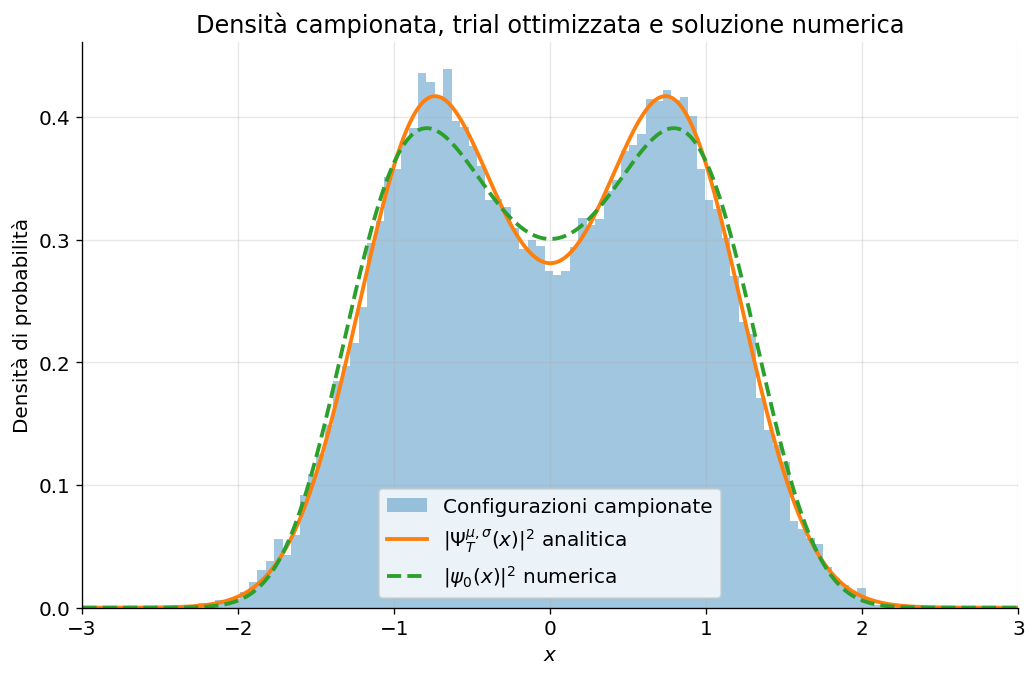

Numero di configurazioni campionate: 100000


In [8]:
def psi_trial(x, mu, sigma):
    return (
        np.exp(-((x - mu)**2) / (2.0 * sigma**2))
        + np.exp(-((x + mu)**2) / (2.0 * sigma**2))
    )


def normalize_density(y, x):
    return y / np.trapezoid(y, x)


def trial_density(x, mu, sigma):
    values = psi_trial(x, mu, sigma)
    return normalize_density(values**2, x)


samples = read_table("sampled_positions_08_3.txt", ["x"])
x_samples = samples["x"].values

x_grid = np.linspace(-3.0, 3.0, 1200)
trial_prob = trial_density(x_grid, final_mu, final_sigma)
mask_exact = (x_exact >= -3.0) & (x_exact <= 3.0)

fig, ax = plt.subplots(figsize=(8.8, 5.8))
ax.hist(
    x_samples,
    bins=90,
    density=True,
    alpha=0.42,
    label="Configurazioni campionate",
)
ax.plot(
    x_grid,
    trial_prob,
    linewidth=2.3,
    label=r"$|\Psi_T^{\mu,\sigma}(x)|^2$ analitica",
)
ax.plot(
    x_exact[mask_exact],
    psi0[mask_exact]**2,
    linestyle="--",
    linewidth=2.3,
    label=r"$|\psi_0(x)|^2$ numerica",
)
ax.set_xlim(-3, 3)
ax.set_xlabel(r"$x$")
ax.set_ylabel("Densità di probabilità")
ax.set_title("Densità campionata, trial ottimizzata e soluzione numerica")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Numero di configurazioni campionate: {len(x_samples)}")

## Commento finale

L'istogramma delle configurazioni campionate segue bene la densità analitica della funzione trial ottimizzata. Questo conferma che il Metropolis della run finale sta campionando correttamente $|\Psi_T(x)|^2$.

Il confronto con $|\psi_0(x)|^2$ mostra invece la qualità dell'ansatz variazionale. La forma a due gaussiane riproduce la struttura a doppia buca dello stato fondamentale, ma non coincide perfettamente con la soluzione numerica esatta. Di conseguenza l'energia variazionale finale resta maggiore di $E_0$, come previsto dal principio variazionale.

In conclusione, il Simulated Annealing permette di individuare una buona regione nello spazio $(\mu,\sigma)$; il controllo del best evita di selezionare una fluttuazione Monte Carlo troppo favorevole; la VMC finale con $100$ blocchi da $10000$ passi fornisce la stima affidabile dell'energia da riportare.